# 🐟 Atlantic Salmon Length & Weight Estimation using YOLOv8
**Author: Daniel Oluwole Bisiriyu**

This notebook demonstrates a computer vision pipeline for:
- Detecting Atlantic Salmon in images using YOLOv8
- Estimating fish **length** from bounding box dimensions with scale calibration
- Predicting fish **weight** using the Atlantic Salmon allometric formula: `W = a × L^b`

This approach mirrors techniques used in precision aquaculture by companies like Aquabyte and Optoscale.

> **Reference:** Jonsson & Jonsson (2011); Feed cost ~50% of salmon production cost (Ytrestøyl et al., 2020)


## 📦 Step 1: Install Dependencies

In [1]:
!pip install ultralytics roboflow opencv-python-headless matplotlib --quiet

## 📂 Step 2: Download Salmon Dataset from Roboflow
579 labelled salmon images at 640×640 — instance segmentation dataset.

In [2]:
!pip install roboflow
from roboflow import Roboflow

rf = Roboflow(api_key="iL4PT2Av5iwWsZfVdFwd")
project = rf.workspace("slimi-rahma").project("salmon-lyajd")
version = project.version(1)
dataset = version.download("yolov8")

print(f"\n✅ Dataset downloaded to: {dataset.location}")

loading Roboflow workspace...
loading Roboflow project...

✅ Dataset downloaded to: /content/Salmon-1


## 🔍 Step 3: Inspect the Dataset

📁 train: 579 images


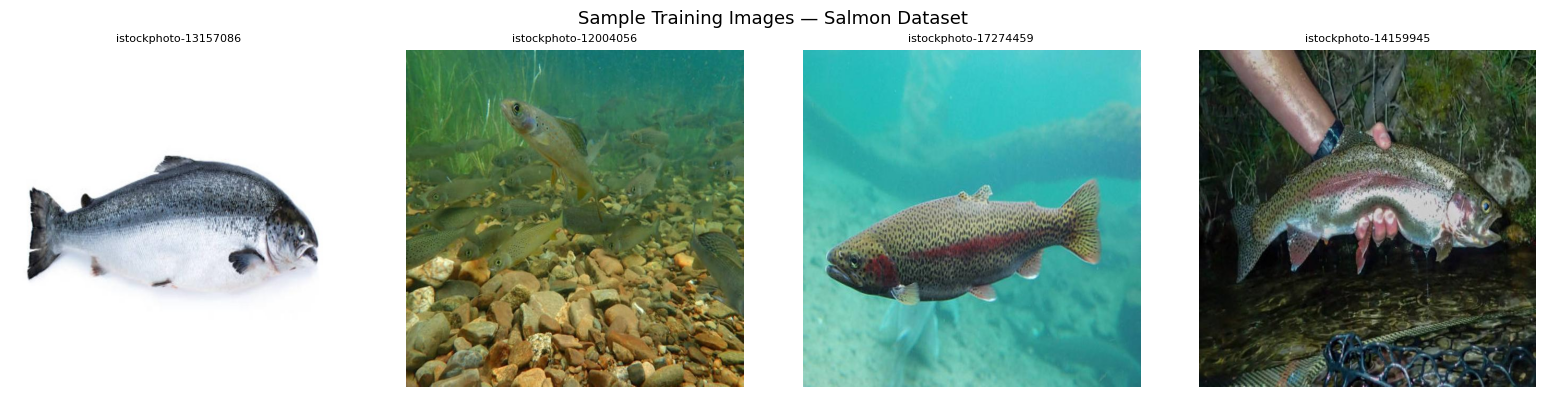

In [3]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Print split sizes
for split in ['train', 'valid', 'test']:
    img_dir = os.path.join(dataset.location, split, 'images')
    if os.path.exists(img_dir):
        count = len(os.listdir(img_dir))
        print(f"📁 {split}: {count} images")

# Preview 4 sample training images
train_img_dir = os.path.join(dataset.location, 'train', 'images')
sample_imgs   = os.listdir(train_img_dir)[:4]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, img_name in zip(axes, sample_imgs):
    img = mpimg.imread(os.path.join(train_img_dir, img_name))
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(img_name[:20], fontsize=8)
plt.suptitle('Sample Training Images — Salmon Dataset', fontsize=13)
plt.tight_layout()
plt.show()

## 🤖 Step 4: Train YOLOv8 on Salmon Dataset

In [4]:
from ultralytics import YOLO
import yaml
import os

# YOLOv8 nano — lightweight, fast, good for prototyping on Colab
model = YOLO('yolov8n.pt')

# Path to data.yaml
data_yaml_path = f"{dataset.location}/data.yaml"

# Load data.yaml
with open(data_yaml_path, 'r') as f:
    data_config = yaml.safe_load(f)

# Check if 'val' path exists and if not, point it to 'train'
# This is a workaround if the 'valid/images' directory is missing.
if 'val' in data_config and not os.path.exists(os.path.join(dataset.location, data_config['val'])):
    print(f"⚠️ Warning: Validation path '{data_config['val']}' not found. Pointing 'val' to 'train' path for now.")
    data_config['val'] = data_config['train']

# Also check for 'test' if it exists and is missing
if 'test' in data_config and not os.path.exists(os.path.join(dataset.location, data_config['test'])):
    print(f"⚠️ Warning: Test path '{data_config['test']}' not found. Removing 'test' from data.yaml.")
    del data_config['test']

# Save the modified data.yaml temporarily
modified_data_yaml_path = f"{dataset.location}/data_modified.yaml"
with open(modified_data_yaml_path, 'w') as f:
    yaml.safe_dump(data_config, f)

results = model.train(
    data=modified_data_yaml_path, # Use the modified data.yaml
    epochs=30,
    imgsz=640,
    batch=16,
    name='salmon_detector',
    patience=5,
    verbose=True
)

print("\n✅ Training complete!")

⚠️ Warning: Validation path '../valid/images' not found. Pointing 'val' to 'train' path for now.
⚠️ Warning: Test path '../test/images' not found. Removing 'test' from data.yaml.
Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Salmon-1/data_modified.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=tra

## 📊 Step 5: Evaluate Model Performance

In [5]:
metrics = model.val()

print(f"mAP50:     {metrics.box.map50:.4f}")
print(f"mAP50-95:  {metrics.box.map:.4f}")
print(f"Precision: {metrics.box.mp:.4f}")
print(f"Recall:    {metrics.box.mr:.4f}")

Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1063.7±398.9 MB/s, size: 33.6 KB)
val: Scanning /content/Salmon-1/train/labels.cache... 579 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 579/579 121.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 37/37 5.5it/s 6.7s
                   all        579       1098      0.966      0.974      0.989      0.922
Speed: 1.5ms preprocess, 4.1ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to /content/runs/detect/val2
mAP50:     0.9889
mAP50-95:  0.9220
Precision: 0.9658
Recall:    0.9736


In [10]:
import os
for root, dirs, files in os.walk('/content'):
    for file in files:
        if file == 'best.pt':
            print(os.path.join(root, file))

/content/runs/detect/salmon_detector2/weights/best.pt
/content/runs/detect/salmon_detector/weights/best.pt


In [11]:
import glob

# Auto-find the latest best.pt
model_paths = glob.glob('/content/runs/detect/salmon_detector*/weights/best.pt')
latest_model = sorted(model_paths)[-1]
print(f"✅ Using model: {latest_model}")

model = YOLO(latest_model)

✅ Using model: /content/runs/detect/salmon_detector2/weights/best.pt


## 📏 Step 6: Length & Weight Estimation Pipeline

### How it works:
1. YOLOv8 detects salmon → returns a **bounding box** in pixels
2. A **reference object** of known size in the image gives a **pixel-to-cm scale factor**
3. Fish length (cm) = bounding box width (px) × scale factor
4. Weight predicted using Atlantic Salmon allometric formula:
   > **W = a × L^b** — a=0.0104, b=3.05 (Salmo salar, Jonsson & Jonsson 2011)

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
import glob

A = 0.0104
B = 3.05

def estimate_length_cm(bbox_width_px, reference_px, reference_cm=10.0):
    """Convert bounding box pixel width to real-world cm using a reference object."""
    scale = reference_cm / reference_px
    return bbox_width_px * scale

def estimate_weight_g(length_cm, a=A, b=B):
    """Predict weight (g) from length (cm) using allometric formula W = a * L^b."""
    return a * (length_cm ** b)

def run_pipeline(image_path, reference_px=100, reference_cm=10.0,
                 conf_threshold=0.4, silent=False):
    """Full pipeline: detect salmon → estimate length → predict weight."""
    # Auto-find latest trained model
    model_paths  = glob.glob('/content/runs/detect/salmon_detector*/weights/best.pt')
    latest_model = sorted(model_paths)[-1]
    print(f"✅ Using model: {latest_model}")

    model    = YOLO(latest_model)
    results  = model(image_path, conf=conf_threshold, verbose=False)[0]
    img      = cv2.imread(image_path)
    img_rgb  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    fish_data = []

    for i, box in enumerate(results.boxes):
        x1, y1, x2, y2  = map(int, box.xyxy[0])
        confidence       = float(box.conf[0])
        bbox_width_px    = x2 - x1
        length_cm        = estimate_length_cm(bbox_width_px, reference_px, reference_cm)
        weight_g         = estimate_weight_g(length_cm)

        fish_data.append({
            'fish_id'      : i + 1,
            'bbox_width_px': bbox_width_px,
            'length_cm'    : round(length_cm, 2),
            'weight_g'     : round(weight_g, 2),
            'confidence'   : round(confidence, 3)
        })

        label = f"#{i+1} | {length_cm:.1f}cm | {weight_g:.0f}g"
        cv2.rectangle(img_rgb, (x1, y1), (x2, y2), (0, 200, 100), 2)
        cv2.putText(img_rgb, label, (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 200, 100), 2)

    if not silent:
        plt.figure(figsize=(12, 8))
        plt.imshow(img_rgb)
        plt.axis('off')
        plt.title(f"YOLOv8 Salmon Detection — {len(fish_data)} fish detected", fontsize=14)
        plt.tight_layout()
        plt.show()

    return fish_data

print("✅ Pipeline functions loaded.")

✅ Pipeline functions loaded.


## 🖼️ Step 7: Run on a Validation Image

✅ Total images available: 579
Running on: /content/Salmon-1/train/images/istockphoto-1315708602-612x612_jpg.rf.c102262ea26c0e9f804e7ea2cfa8cb71.jpg
✅ Using model: /content/runs/detect/salmon_detector2/weights/best.pt


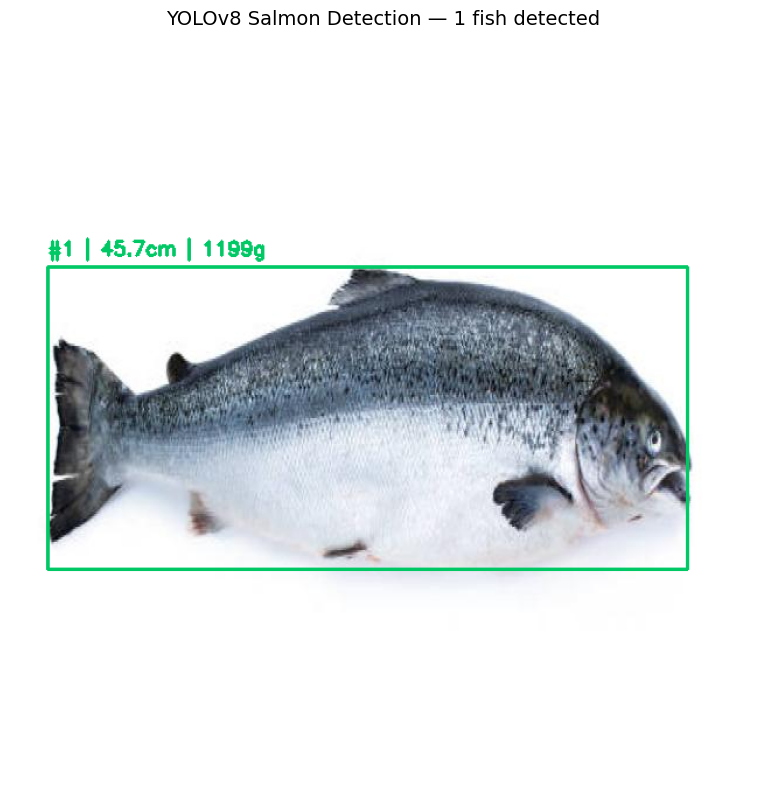


📋 Detection Results:
 fish_id  bbox_width_px  length_cm  weight_g  confidence
       1            548      45.67   1198.98       0.955


In [13]:
import pandas as pd
import os

# Only 'train' folder exists in this dataset
train_img_dir = os.path.join(dataset.location, 'train', 'images')
all_images    = os.listdir(train_img_dir)

print(f"✅ Total images available: {len(all_images)}")

# Pick one image to test on
TEST_IMAGE = os.path.join(train_img_dir, all_images[0])
print(f"Running on: {TEST_IMAGE}")

REFERENCE_PX = 120
REFERENCE_CM = 10.0

fish_results = run_pipeline(TEST_IMAGE, REFERENCE_PX, REFERENCE_CM)

df = pd.DataFrame(fish_results)
print("\n📋 Detection Results:")
print(df.to_string(index=False))

VISUALIZE THE RESULT OF THE 1 VALID TEST

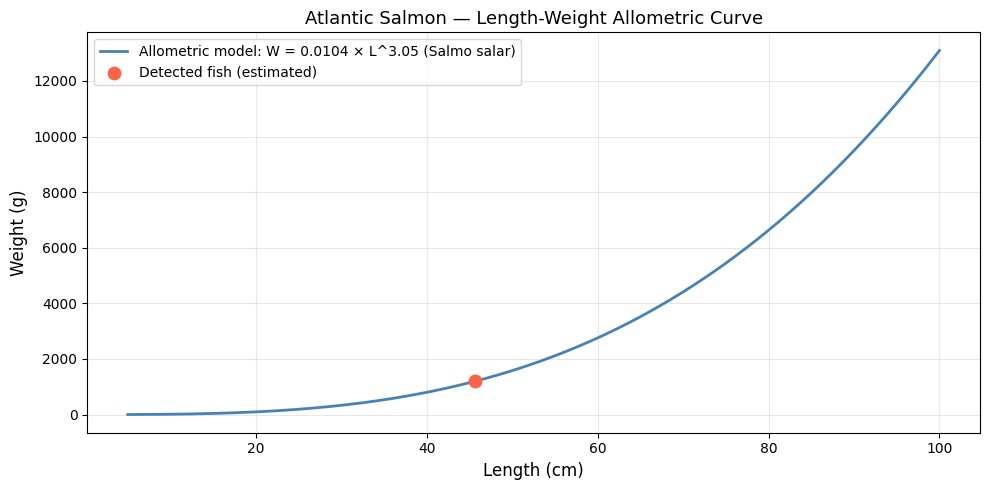

In [16]:
lengths = np.linspace(5, 100, 300)
weights = A * (lengths ** B)

plt.figure(figsize=(10, 5))
plt.plot(lengths, weights, color='steelblue', linewidth=2,
         label='Allometric model: W = 0.0104 × L^3.05 (Salmo salar)')

if fish_results:
    det_l = [f['length_cm'] for f in fish_results]
    det_w = [f['weight_g']  for f in fish_results]
    plt.scatter(det_l, det_w, color='tomato', zorder=5,
                s=80, label='Detected fish (estimated)')

plt.xlabel('Length (cm)', fontsize=12)
plt.ylabel('Weight (g)', fontsize=12)
plt.title('Atlantic Salmon — Length-Weight Allometric Curve', fontsize=13)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

train_img_dir = os.path.join(dataset.location, 'train', 'images')
all_images    = os.listdir(train_img_dir)

print(f"🐟 Running on {len(all_images)} images silently...\n")

all_results = []

for idx, img_name in enumerate(all_images):
    img_path = os.path.join(train_img_dir, img_name)
    results  = run_pipeline(img_path, reference_px=120,
                            reference_cm=10.0, conf_threshold=0.4,
                            silent=True)
    for fish in results:
        fish['image'] = img_name
        all_results.append(fish)

    if (idx + 1) % 50 == 0:
        print(f"   ✅ Processed {idx + 1}/{len(all_images)} images...")

df = pd.DataFrame(all_results)
print(f"\n🎉 Done! Total salmon detected: {len(df)}")
print(f"   Mean length : {df['length_cm'].mean():.1f} cm")
print(f"   Mean weight : {df['weight_g'].mean():.0f} g ({df['weight_g'].mean()/1000:.2f} kg)")

🐟 Running on 579 images silently...

✅ Using model: /content/runs/detect/salmon_detector2/weights/best.pt
✅ Using model: /content/runs/detect/salmon_detector2/weights/best.pt
✅ Using model: /content/runs/detect/salmon_detector2/weights/best.pt
✅ Using model: /content/runs/detect/salmon_detector2/weights/best.pt
✅ Using model: /content/runs/detect/salmon_detector2/weights/best.pt
✅ Using model: /content/runs/detect/salmon_detector2/weights/best.pt
✅ Using model: /content/runs/detect/salmon_detector2/weights/best.pt
✅ Using model: /content/runs/detect/salmon_detector2/weights/best.pt
✅ Using model: /content/runs/detect/salmon_detector2/weights/best.pt
✅ Using model: /content/runs/detect/salmon_detector2/weights/best.pt
✅ Using model: /content/runs/detect/salmon_detector2/weights/best.pt
✅ Using model: /content/runs/detect/salmon_detector2/weights/best.pt
✅ Using model: /content/runs/detect/salmon_detector2/weights/best.pt
✅ Using model: /content/runs/detect/salmon_detector2/weights/best.

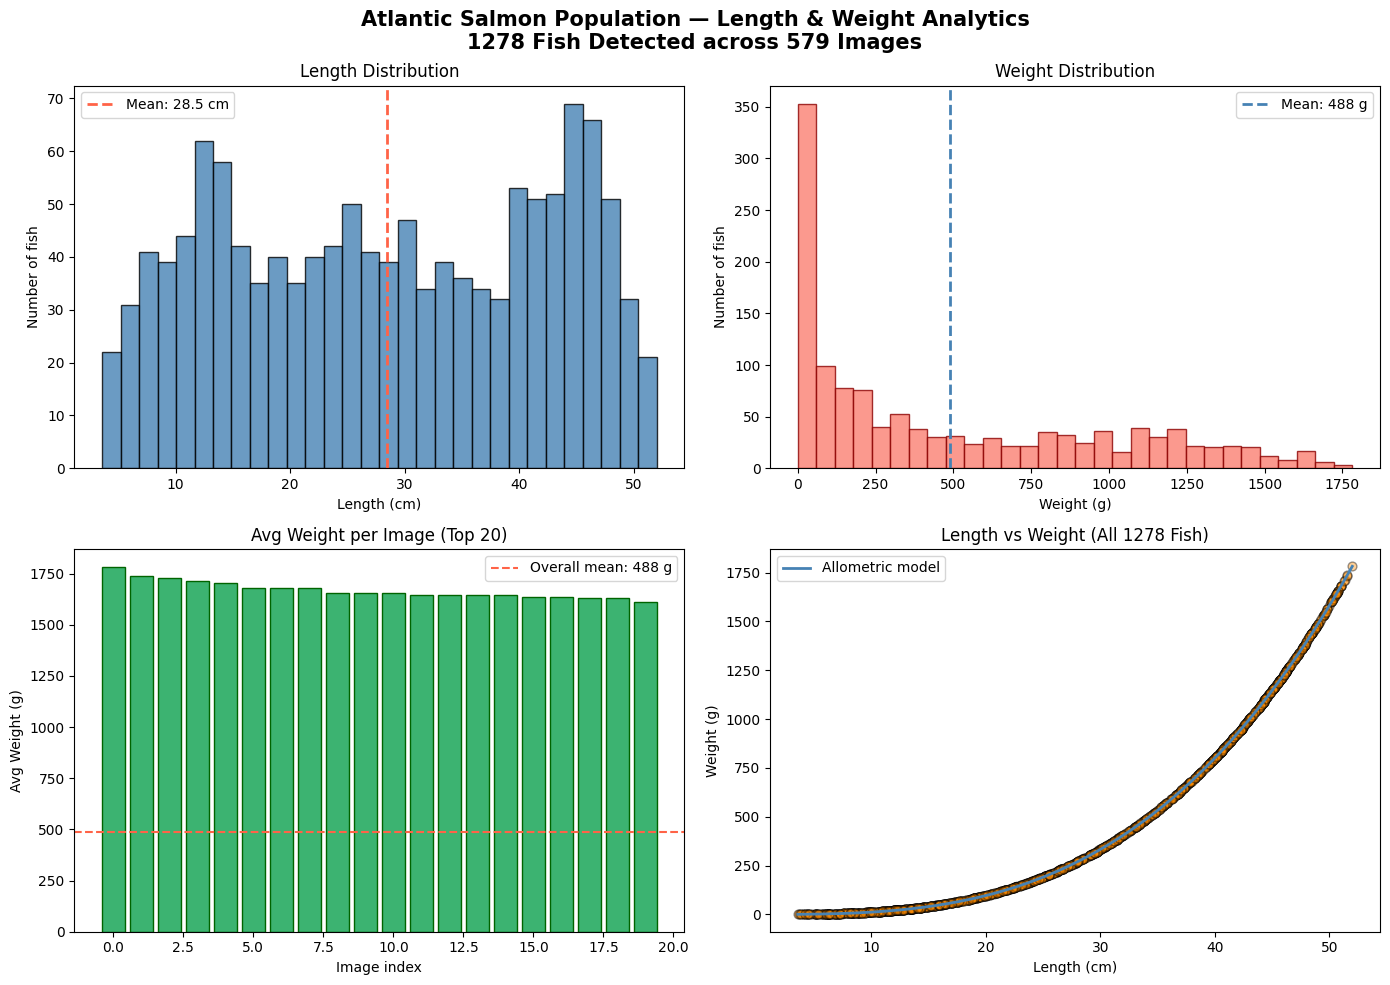


📊 Population Summary:
   Images processed    : 579
   Total fish detected : 1278
   Mean length         : 28.5 cm
   Mean weight         : 488 g  (0.49 kg)
   Heaviest fish       : 1782 g  (1.78 kg)
   Lightest fish       : 1 g
   Total biomass est.  : 623.80 kg


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Atlantic Salmon Population — Length & Weight Analytics\n1278 Fish Detected across 579 Images',
             fontsize=15, fontweight='bold')

# 1. Length distribution
axes[0, 0].hist(df['length_cm'], bins=30, color='steelblue',
                edgecolor='black', alpha=0.8)
axes[0, 0].axvline(df['length_cm'].mean(), color='tomato', linewidth=2,
                   linestyle='--',
                   label=f"Mean: {df['length_cm'].mean():.1f} cm")
axes[0, 0].set_title('Length Distribution')
axes[0, 0].set_xlabel('Length (cm)')
axes[0, 0].set_ylabel('Number of fish')
axes[0, 0].legend()

# 2. Weight distribution
axes[0, 1].hist(df['weight_g'], bins=30, color='salmon',
                edgecolor='darkred', alpha=0.8)
axes[0, 1].axvline(df['weight_g'].mean(), color='steelblue', linewidth=2,
                   linestyle='--',
                   label=f"Mean: {df['weight_g'].mean():.0f} g")
axes[0, 1].set_title('Weight Distribution')
axes[0, 1].set_xlabel('Weight (g)')
axes[0, 1].set_ylabel('Number of fish')
axes[0, 1].legend()

# 3. Average weight per image (bar chart)
avg_per_img = df.groupby('image')['weight_g'].mean().sort_values(ascending=False).head(20)
axes[1, 0].bar(range(len(avg_per_img)), avg_per_img.values,
               color='mediumseagreen', edgecolor='darkgreen')
axes[1, 0].axhline(df['weight_g'].mean(), color='tomato', linestyle='--',
                   label=f"Overall mean: {df['weight_g'].mean():.0f} g")
axes[1, 0].set_title('Avg Weight per Image (Top 20)')
axes[1, 0].set_xlabel('Image index')
axes[1, 0].set_ylabel('Avg Weight (g)')
axes[1, 0].legend()

# 4. Length vs Weight scatter
axes[1, 1].scatter(df['length_cm'], df['weight_g'],
                   alpha=0.4, color='darkorange',
                   edgecolors='black', s=40)
curve_l = np.linspace(df['length_cm'].min(), df['length_cm'].max(), 300)
curve_w = A * (curve_l ** B)
axes[1, 1].plot(curve_l, curve_w, 'steelblue', linewidth=2,
                label='Allometric model')
axes[1, 1].set_title('Length vs Weight (All 1278 Fish)')
axes[1, 1].set_xlabel('Length (cm)')
axes[1, 1].set_ylabel('Weight (g)')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# ── Summary ────────────────────────────────────────────────────────────────
print("\n📊 Population Summary:")
print(f"   Images processed    : 579")
print(f"   Total fish detected : {len(df)}")
print(f"   Mean length         : {df['length_cm'].mean():.1f} cm")
print(f"   Mean weight         : {df['weight_g'].mean():.0f} g  ({df['weight_g'].mean()/1000:.2f} kg)")
print(f"   Heaviest fish       : {df['weight_g'].max():.0f} g  ({df['weight_g'].max()/1000:.2f} kg)")
print(f"   Lightest fish       : {df['weight_g'].min():.0f} g")
print(f"   Total biomass est.  : {df['weight_g'].sum()/1000:.2f} kg")

✅ Total images available: 579
Running on: /content/Salmon-1/train/images/istockphoto-1315708602-612x612_jpg.rf.c102262ea26c0e9f804e7ea2cfa8cb71.jpg
✅ Using model: /content/runs/detect/salmon_detector2/weights/best.pt


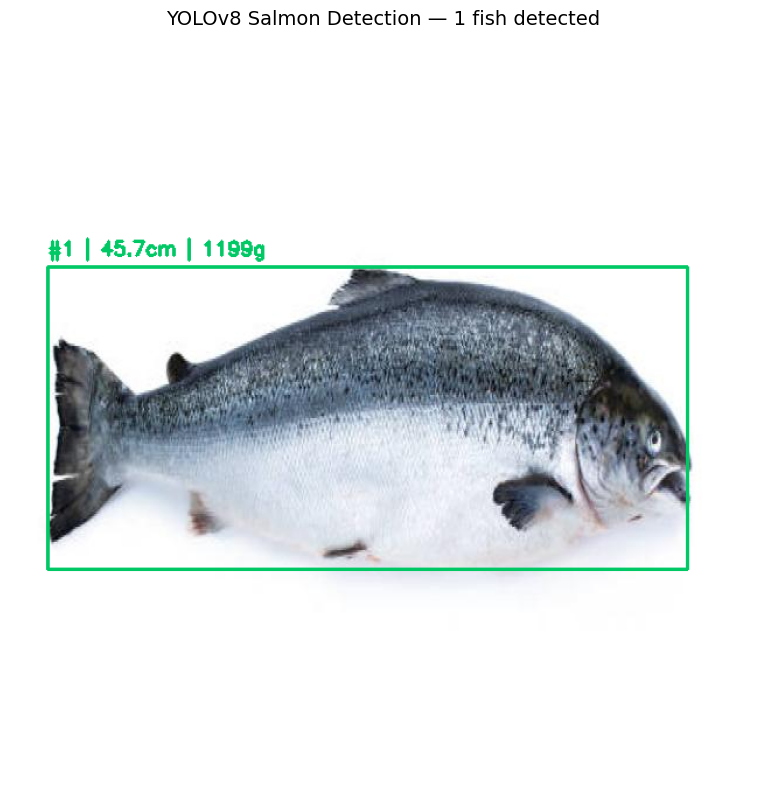


📋 Detection Results:
 fish_id  bbox_width_px  length_cm  weight_g  confidence
       1            548      45.67   1198.98       0.955


In [17]:
import pandas as pd
import os

# Only 'train' folder exists in this dataset
train_img_dir = os.path.join(dataset.location, 'train', 'images')
all_images    = os.listdir(train_img_dir)

print(f"✅ Total images available: {len(all_images)}")

# Pick one image to test on
TEST_IMAGE = os.path.join(train_img_dir, all_images[0])
print(f"Running on: {TEST_IMAGE}")

# Calibration
REFERENCE_PX = 120
REFERENCE_CM = 10.0

fish_results = run_pipeline(TEST_IMAGE, REFERENCE_PX, REFERENCE_CM)

df = pd.DataFrame(fish_results)
print("\n📋 Detection Results:")
print(df.to_string(index=False))

## 📈 Step 8: Visualise Length-Weight Allometric Curve

## 🧪 Step 9: Simulate Predictions (Running This First — No Training Needed!)
Validate the pipeline logic immediately using synthetic Atlantic Salmon data.

📋 Simulated Fish Sample (first 10):
 fish_id  length_cm  weight_g  weight_kg
       1      52.47   1899.19      1.899
       2      87.04   8648.18      8.648
       3      73.92   5178.84      5.179
       4      65.92   3617.74      3.618
       5      39.36    705.72      0.706
       6      39.36    734.55      0.735
       7      33.49    454.68      0.455
       8      81.97   7517.25      7.517
       9      66.07   3761.69      3.762
      10      72.48   4474.05      4.474

📊 Mean length : 56.8 cm
📊 Mean weight : 3004 g  (3.00 kg)


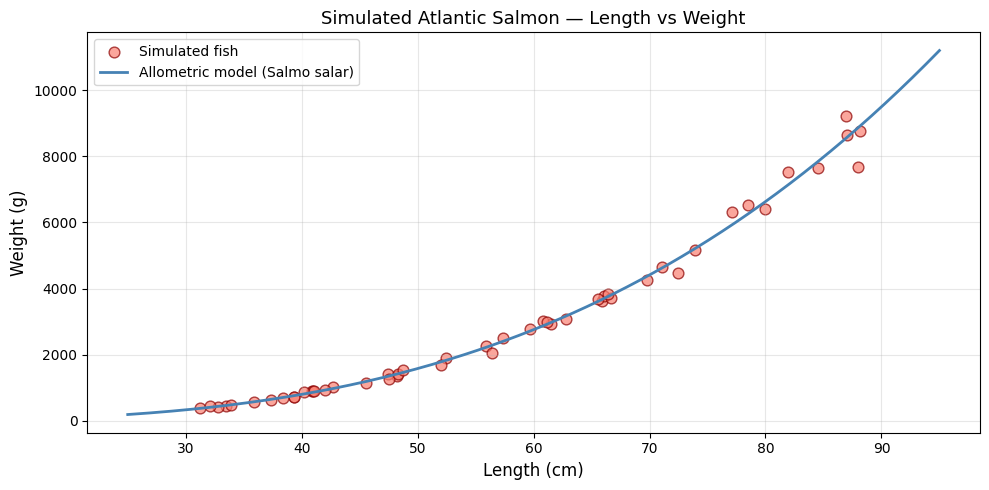

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
A, B = 0.0104, 3.05

n_fish      = 50
sim_lengths = np.random.uniform(30, 90, n_fish)
noise       = np.random.normal(1.0, 0.05, n_fish)  # ±5% biological variation
sim_weights = A * (sim_lengths ** B) * noise

sim_df = pd.DataFrame({
    'fish_id'  : range(1, n_fish + 1),
    'length_cm': np.round(sim_lengths, 2),
    'weight_g' : np.round(sim_weights, 2),
    'weight_kg': np.round(sim_weights / 1000, 3)
})

print("📋 Simulated Fish Sample (first 10):")
print(sim_df.head(10).to_string(index=False))
print(f"\n📊 Mean length : {sim_df.length_cm.mean():.1f} cm")
print(f"📊 Mean weight : {sim_df.weight_g.mean():.0f} g  ({sim_df.weight_kg.mean():.2f} kg)")

curve_l = np.linspace(25, 95, 300)
curve_w = A * (curve_l ** B)

plt.figure(figsize=(10, 5))
plt.scatter(sim_df.length_cm, sim_df.weight_g,
            alpha=0.7, color='salmon', edgecolors='darkred',
            s=60, label='Simulated fish')
plt.plot(curve_l, curve_w, 'steelblue', linewidth=2,
         label='Allometric model (Salmo salar)')
plt.xlabel('Length (cm)', fontsize=12)
plt.ylabel('Weight (g)', fontsize=12)
plt.title('Simulated Atlantic Salmon — Length vs Weight', fontsize=13)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## ✅ Summary

| Component | Approach |
|---|---|
| Object detection | YOLOv8n (Ultralytics) |
| Dataset | Salmon — Roboflow (579 images, 640×640) |
| Length estimation | Bounding box width × pixel-to-cm scale factor |
| Weight prediction | Allometric formula W = aL^b (Salmo salar) |
| Simulation | Synthetic data with ±5% biological noise |

### 🚀 Possible Extensions
- **Stereo / depth camera** → true 3D length without a reference object
- **CNN regression** → end-to-end image → weight prediction
- **Behaviour detection** → classify feeding vs resting posture for autonomous feed control
- **Multi-fish tracking** → DeepSORT for individual tracking across video frames
- **Health scoring** → detect lice, wounds, or deformities from bounding box crops
